<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/Chapter05Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import files
uploaded = files.upload()

Saving Chapter05DataSet.csv to Chapter05DataSet (1).csv


In [27]:
import os
os.listdir()

['.config', 'Chapter05DataSet.csv', 'Chapter05DataSet (1).csv', 'sample_data']

In [28]:
import pandas as pd

Chapter05DataSet = pd.read_csv('Chapter05DataSet.csv')
Chapter05DataSet.head()

,Elapsed_Time,Time_in_Community,Gender,Working,Age,Family,Hobbies,Social_Club,Political,Professional,Religious,Support_Group
0,8.71,Short,M,No,53,1,0,0,0,0,0,0
1,5.24,Medium,F,No,31,0,0,0,0,0,1,1
2,4.22,Medium,M,No,42,1,1,0,0,1,0,0
3,4.81,Long,F,No,30,0,0,0,0,0,0,0
4,3.95,Long,M,Yes,29,0,0,0,1,1,0,1


In [11]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
!pip install mlxtend

In [36]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

In [34]:
df_selected = Chapter05DataSet[['Family', 'Hobbies', 'Political', 'Professional', 'Religious', 'Social_Club', 'Support_Group']]
df_selected.head()

,Family,Hobbies,Political,Professional,Religious,Social_Club,Support_Group
0,1,0,0,0,0,0,0
1,0,0,0,0,1,0,1
2,1,1,0,1,0,0,0
3,0,0,0,0,0,0,0
4,0,0,1,1,0,0,1


In [35]:
df_bool = df_selected.astype(bool)
df_bool.head()

,Family,Hobbies,Political,Professional,Religious,Social_Club,Support_Group
0,True,False,False,False,False,False,False
1,False,False,False,False,True,False,True
2,True,True,False,True,False,False,False
3,False,False,False,False,False,False,False
4,False,False,True,True,False,False,True


In [37]:
frequent_fp = fpgrowth(df_bool, min_support=0.2, use_colnames=True)
frequent_fp.sort_values(by='support', ascending=False)

,support,itemsets
1,0.418605,(Religious)
0,0.389894,(Family)
2,0.324433,(Professional)
3,0.300029,(Hobbies)
5,0.238875,"(Religious, Hobbies)"
4,0.224519,"(Family, Religious)"


In [38]:
rules_fp = association_rules(frequent_fp, metric="confidence", min_threshold=0.5)
rules_fp.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(Hobbies),(Religious),0.300029,0.418605,0.238875,0.796172,1.901967,1.0,0.113281,2.852386,0.677497,0.497905,0.649416,0.683408
0,(Family),(Religious),0.389894,0.418605,0.224519,0.575847,1.375634,1.0,0.061308,1.370720,0.447566,0.384464,0.270457,0.556099
2,(Religious),(Hobbies),0.418605,0.300029,0.238875,0.570645,1.901967,1.0,0.113281,1.630285,0.815673,0.497905,0.386610,0.683408
1,(Religious),(Family),0.418605,0.389894,0.224519,0.536351,1.375634,1.0,0.061308,1.315880,0.469668,0.384464,0.240052,0.556099


In [40]:
rules_fp[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
0,(Family),(Religious),0.224519,0.575847,1.375634
1,(Religious),(Family),0.224519,0.536351,1.375634
2,(Religious),(Hobbies),0.238875,0.570645,1.901967
3,(Hobbies),(Religious),0.238875,0.796172,1.901967


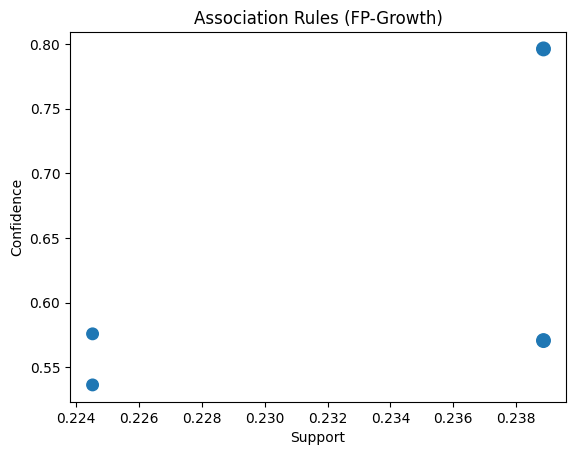

In [43]:
plt.scatter(rules_fp['support'], rules_fp['confidence'], s=rules_fp['lift']*50)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules (FP-Growth)')
plt.show()